In [1]:
# Impact of RAM Capacity on Smartphone Pricing

## Statistical and Multiple Linear Regression Analysis

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(r'C:\Users\Aditya\Desktop\Stats Project\smartphones.csv')

df.head()

,smartphone_brand,model,price_inr,rating_score,processor_name,processor_brand,core_count,clock_speed_ghz,ram_gb,storage_gb,...,battery_mah,fast_charging,charging_watt,rear_camera_count,front_camera_count,rear_camera_main_mp,front_camera_main_mp,os_name,memory_card_supported,memory_card_type
0,blackzone,BlackZone S25 Ultra Maxx,8999,63,unisoc sc9863a1,unisoc,8,1.6,8,128,...,5000,False,10.0,1,1,32.0,16.0,android,NaN,NaN
1,ringme,Ringme Bold P70,5800,44,mediatek helio,mediatek,2,1.3,4,128,...,3260,False,10.0,1,0,13.0,NaN,android,NaN,NaN
2,lava,Lava Shark 5G (4GB RAM + 128GB),8998,60,unisoc t765,unisoc,8,2.3,4,128,...,5000,True,10.0,1,1,13.0,5.0,android,True,dedicated
3,vivo,Vivo Y19s 5G (4GB RAM + 128GB),11999,69,mediatek dimensity 6300,mediatek,8,2.4,4,128,...,6000,True,15.0,2,1,13.0,5.0,android,True,dedicated
4,vivo,Vivo Y19s 5G (4GB RAM + 64GB),10999,68,mediatek dimensity 6300,mediatek,8,2.4,4,64,...,6000,True,15.0,2,1,13.0,5.0,android,True,dedicated


In [3]:
df.shape

(758, 27)

In [4]:
df.columns

Index(['smartphone_brand', 'model', 'price_inr', 'rating_score',
       'processor_name', 'processor_brand', 'core_count', 'clock_speed_ghz',
       'ram_gb', 'storage_gb', 'has_5g', 'has_nfc', 'has_ir_blaster',
       'display_inches', 'res_width_px', 'res_height_px', 'refresh_rate_hz',
       'battery_mah', 'fast_charging', 'charging_watt', 'rear_camera_count',
       'front_camera_count', 'rear_camera_main_mp', 'front_camera_main_mp',
       'os_name', 'memory_card_supported', 'memory_card_type'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 758 entries, 0 to 757
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   smartphone_brand       758 non-null    object 
 1   model                  758 non-null    object 
 2   price_inr              758 non-null    int64  
 3   rating_score           758 non-null    int64  
 4   processor_name         758 non-null    object 
 5   processor_brand        758 non-null    object 
 6   core_count             758 non-null    int64  
 7   clock_speed_ghz        758 non-null    float64
 8   ram_gb                 758 non-null    int64  
 9   storage_gb             758 non-null    int64  
 10  has_5g                 758 non-null    bool   
 11  has_nfc                758 non-null    bool   
 12  has_ir_blaster         758 non-null    bool   
 13  display_inches         758 non-null    float64
 14  res_width_px           758 non-null    int64  
 15  res_he

In [6]:
df.describe(include="all")

,smartphone_brand,model,price_inr,rating_score,processor_name,processor_brand,core_count,clock_speed_ghz,ram_gb,storage_gb,...,battery_mah,fast_charging,charging_watt,rear_camera_count,front_camera_count,rear_camera_main_mp,front_camera_main_mp,os_name,memory_card_supported,memory_card_type
count,758,758,758.000000,758.000000,758,758,758.000000,758.000000,758.000000,758.000000,...,758.000000,758,758.000000,758.000000,758.000000,758.000000,753.000000,758,551,551
unique,26,758,NaN,NaN,125,6,NaN,NaN,NaN,NaN,...,NaN,2,NaN,NaN,NaN,NaN,NaN,2,2,2
top,realme,BlackZone S25 Ultra Maxx,NaN,NaN,mediatek dimensity 6300,mediatek,NaN,NaN,NaN,NaN,...,NaN,True,NaN,NaN,NaN,NaN,NaN,android,True,dedicated
freq,134,1,NaN,NaN,117,388,NaN,NaN,NaN,NaN,...,NaN,746,NaN,NaN,NaN,NaN,NaN,730,383,326
mean,NaN,NaN,29424.088391,78.587071,NaN,NaN,7.906332,2.597889,7.990765,220.496042,...,5373.569921,NaN,45.982850,2.110818,1.015831,52.234828,19.446879,NaN,NaN,NaN
std,NaN,NaN,32989.687389,8.372894,NaN,NaN,0.701338,0.596162,3.134361,168.366358,...,980.222628,NaN,28.744416,0.707285,0.169738,26.662235,14.483133,NaN,NaN,NaN
min,NaN,NaN,4040.000000,37.000000,NaN,NaN,1.000000,1.000000,2.000000,32.000000,...,2000.000000,NaN,5.000000,1.000000,0.000000,8.000000,5.000000,NaN,NaN,NaN
25%,NaN,NaN,11857.250000,74.000000,NaN,NaN,8.000000,2.300000,6.000000,128.000000,...,5000.000000,NaN,25.000000,2.000000,1.000000,50.000000,8.000000,NaN,NaN,NaN
50%,NaN,NaN,18999.000000,80.000000,NaN,NaN,8.000000,2.400000,8.000000,128.000000,...,5000.000000,NaN,44.000000,2.000000,1.000000,50.000000,13.000000,NaN,NaN,NaN
75%,NaN,NaN,29990.000000,84.000000,NaN,NaN,8.000000,2.800000,8.000000,256.000000,...,6000.000000,NaN,68.000000,3.000000,1.000000,50.000000,32.000000,NaN,NaN,NaN


In [7]:
df.isnull().sum()

smartphone_brand           0
model                      0
price_inr                  0
rating_score               0
processor_name             0
processor_brand            0
core_count                 0
clock_speed_ghz            0
ram_gb                     0
storage_gb                 0
has_5g                     0
has_nfc                    0
has_ir_blaster             0
display_inches             0
res_width_px               0
res_height_px              0
refresh_rate_hz            0
battery_mah                0
fast_charging              0
charging_watt              0
rear_camera_count          0
front_camera_count         0
rear_camera_main_mp        0
front_camera_main_mp       5
os_name                    0
memory_card_supported    207
memory_card_type         207
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [12]:
Q1 = df["price_inr"].quantile(0.25)
Q3 = df["price_inr"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["price_inr"] < lower) |
    (df["price_inr"] > upper)
]

print("Number of outliers:", len(outliers))
outliers.head()

Number of outliers: 80


,smartphone_brand,model,price_inr,rating_score,processor_name,processor_brand,core_count,clock_speed_ghz,ram_gb,storage_gb,...,battery_mah,fast_charging,charging_watt,rear_camera_count,front_camera_count,rear_camera_main_mp,front_camera_main_mp,os_name,memory_card_supported,memory_card_type
9,ulefone,Ulefone Armor 29 Pro 5G,86500,96,mediatek dimensity 7400,mediatek,8,2.60,16,512,...,21200,True,120.0,3,1,64.0,50.0,android,True,dedicated
41,apple,Apple iPhone Air (1TB),159900,78,apple a19 pro,apple,6,4.26,8,1024,...,3149,True,27.0,1,1,48.0,18.0,ios,False,dedicated
42,apple,Apple iPhone Air (512GB),139900,78,apple a19 pro,apple,6,4.26,8,512,...,3149,True,27.0,1,1,48.0,18.0,ios,False,dedicated
43,apple,Apple iPhone 17 Pro (1TB),174900,83,apple a19 pro,apple,6,4.26,12,1024,...,3988,True,27.0,3,1,48.0,18.0,ios,False,dedicated
44,apple,Apple iPhone 17 Pro (512GB),154900,83,apple a19 pro,apple,6,4.26,12,512,...,3988,True,27.0,3,1,48.0,18.0,ios,False,dedicated


In [13]:
print("Average RAM:", df["ram_gb"].mean())
print("Average Price:", df["price_inr"].mean())

Average RAM: 7.990765171503957
Average Price: 29424.088390501318


In [14]:
print(df.shape)
print(df[["ram_gb", "storage_gb", "price_inr"]].head(10))
print(df[["ram_gb", "storage_gb", "price_inr"]].isnull().sum())
print(df[["ram_gb", "storage_gb", "price_inr"]].describe())

(758, 27)
   ram_gb  storage_gb  price_inr
0       8         128       8999
1       4         128       5800
2       4         128       8998
3       4         128      11999
4       4          64      10999
5       6         128      13499
6       8         256      20999
7       8         128      15999
8       3          32       5599
9      16         512      86500
ram_gb        0
storage_gb    0
price_inr     0
dtype: int64
           ram_gb   storage_gb      price_inr
count  758.000000   758.000000     758.000000
mean     7.990765   220.496042   29424.088391
std      3.134361   168.366358   32989.687389
min      2.000000    32.000000    4040.000000
25%      6.000000   128.000000   11857.250000
50%      8.000000   128.000000   18999.000000
75%      8.000000   256.000000   29990.000000
max     24.000000  2048.000000  229900.000000


In [16]:
outliers[["smartphone_brand", "model", "ram_gb", "storage_gb", "price_inr"]].head(10)

,smartphone_brand,model,ram_gb,storage_gb,price_inr
9,ulefone,Ulefone Armor 29 Pro 5G,16,512,86500
41,apple,Apple iPhone Air (1TB),8,1024,159900
42,apple,Apple iPhone Air (512GB),8,512,139900
43,apple,Apple iPhone 17 Pro (1TB),12,1024,174900
44,apple,Apple iPhone 17 Pro (512GB),12,512,154900
45,apple,Apple iPhone 17 Pro Max (2TB),12,2048,229900
46,apple,Apple iPhone 17 Pro Max (1TB),12,1024,189900
47,apple,Apple iPhone 17 Pro Max (512GB),12,512,169900
48,apple,Apple iPhone 17 (512GB),8,512,102900
53,samsung,Samsung Galaxy S25 FE (8GB RAM + 512GB),8,512,77999


In [17]:
df[[
    "ram_gb",
    "storage_gb",
    "price_inr"
]].describe()

,ram_gb,storage_gb,price_inr
count,758.000000,758.000000,758.000000
mean,7.990765,220.496042,29424.088391
std,3.134361,168.366358,32989.687389
min,2.000000,32.000000,4040.000000
25%,6.000000,128.000000,11857.250000
50%,8.000000,128.000000,18999.000000
75%,8.000000,256.000000,29990.000000
max,24.000000,2048.000000,229900.000000


In [18]:
print("RAM")
print("Mean:", df["ram_gb"].mean())
print("Median:", df["ram_gb"].median())
print("Standard Deviation:", df["ram_gb"].std())

print("\nPrice")
print("Mean:", df["price_inr"].mean())
print("Median:", df["price_inr"].median())
print("Standard Deviation:", df["price_inr"].std())

RAM
Mean: 7.990765171503957
Median: 8.0
Standard Deviation: 3.134361350930063

Price
Mean: 29424.088390501318
Median: 18999.0
Standard Deviation: 32989.687389299295


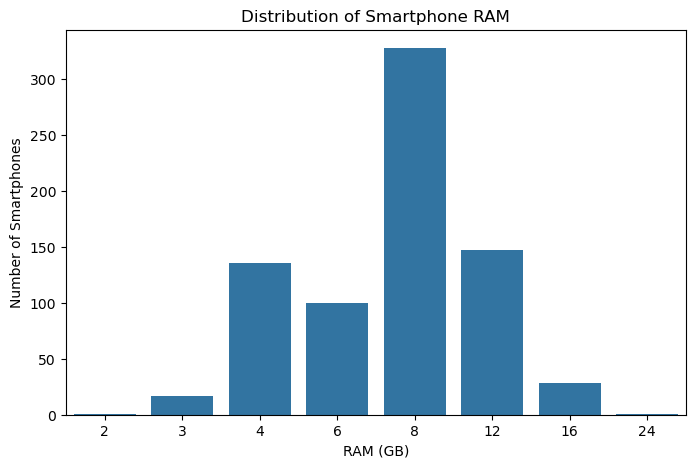

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="ram_gb")

plt.title("Distribution of Smartphone RAM")
plt.xlabel("RAM (GB)")
plt.ylabel("Number of Smartphones")

plt.show()

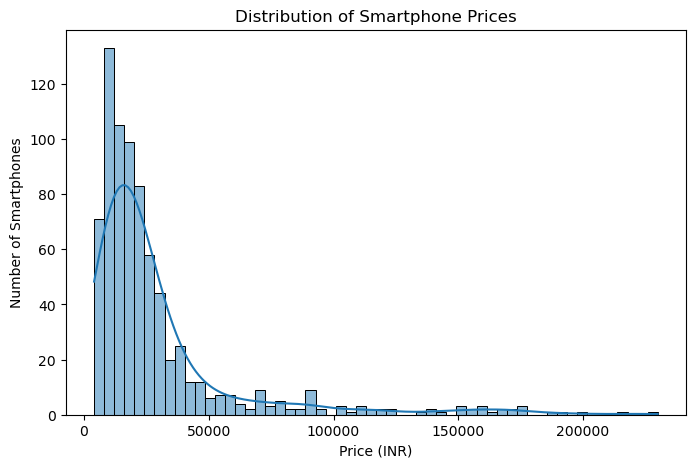

In [21]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="price_inr", kde=True)

plt.title("Distribution of Smartphone Prices")
plt.xlabel("Price (INR)")
plt.ylabel("Number of Smartphones")

plt.show()

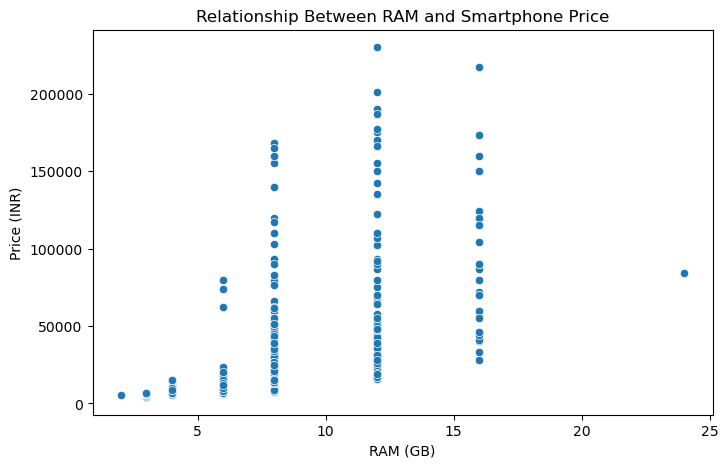

In [22]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="ram_gb",
    y="price_inr"
)

plt.title("Relationship Between RAM and Smartphone Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Price (INR)")

plt.show()

In [23]:
ram_price_correlation = df["ram_gb"].corr(df["price_inr"])

print("Correlation between RAM and Price:", ram_price_correlation)

Correlation between RAM and Price: 0.5480274418535951


In [24]:
ram_price = df.groupby("ram_gb")["price_inr"].agg(
    ["count", "mean", "median", "std"]
)

ram_price

,count,mean,median,std
ram_gb,,,,
2,1,5498.000000,5498.0,NaN
3,17,5921.058824,6099.0,820.630358
4,136,9328.132353,8999.0,2096.774566
6,100,14581.860000,12990.0,10623.764741
8,328,28570.847561,20999.0,25342.198040
12,147,51442.136054,33447.0,44126.522679
16,28,87616.428571,71499.0,47754.207333
24,1,83999.000000,83999.0,NaN


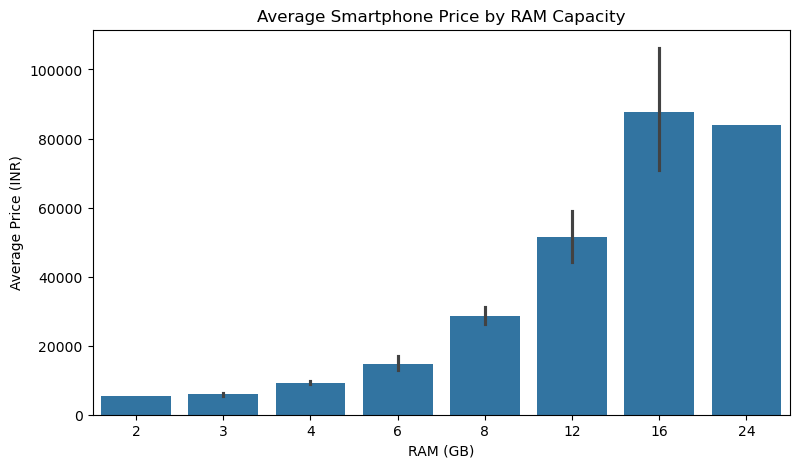

In [25]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="ram_gb",
    y="price_inr"
)

plt.title("Average Smartphone Price by RAM Capacity")
plt.xlabel("RAM (GB)")
plt.ylabel("Average Price (INR)")

plt.show()

In [26]:
numeric_df = df.select_dtypes(include=np.number)

print(numeric_df.columns.tolist())

['price_inr', 'rating_score', 'core_count', 'clock_speed_ghz', 'ram_gb', 'storage_gb', 'display_inches', 'res_width_px', 'res_height_px', 'refresh_rate_hz', 'battery_mah', 'charging_watt', 'rear_camera_count', 'front_camera_count', 'rear_camera_main_mp', 'front_camera_main_mp']


In [27]:
correlation = numeric_df.corr()

correlation

,price_inr,rating_score,core_count,clock_speed_ghz,ram_gb,storage_gb,display_inches,res_width_px,res_height_px,refresh_rate_hz,battery_mah,charging_watt,rear_camera_count,front_camera_count,rear_camera_main_mp,front_camera_main_mp
price_inr,1.000000,0.541073,-0.210701,0.784438,0.548027,0.754398,0.236955,0.589910,0.443512,0.164367,-0.154588,0.132872,0.358635,0.417493,0.272761,0.170803
rating_score,0.541073,1.000000,0.269878,0.691870,0.771104,0.577708,0.379220,0.664906,0.777012,0.526021,0.156140,0.557641,0.635892,0.386629,0.469520,0.577805
core_count,-0.210701,0.269878,1.000000,-0.085716,0.083737,-0.124142,0.613860,0.096476,0.100923,0.294803,0.315754,0.142770,0.108834,0.389763,0.118872,0.023725
clock_speed_ghz,0.784438,0.691870,-0.085716,1.000000,0.623806,0.644367,0.146530,0.570876,0.645516,0.305514,-0.034776,0.370666,0.419235,0.276041,0.290810,0.291964
ram_gb,0.548027,0.771104,0.083737,0.623806,1.000000,0.641805,0.236949,0.632579,0.668330,0.445809,0.173206,0.593220,0.539140,0.278370,0.320298,0.532916
storage_gb,0.754398,0.577708,-0.124142,0.644367,0.641805,1.000000,0.177627,0.509365,0.498588,0.246921,-0.026358,0.326244,0.387709,0.280028,0.240405,0.312503
display_inches,0.236955,0.379220,0.613860,0.146530,0.236949,0.177627,1.000000,0.410310,0.178362,0.309157,0.254976,0.167271,0.128834,0.712909,0.238503,0.058693
res_width_px,0.589910,0.664906,0.096476,0.570876,0.632579,0.509365,0.410310,1.000000,0.641759,0.350077,0.077788,0.458803,0.492697,0.501823,0.333249,0.407821
res_height_px,0.443512,0.777012,0.100923,0.645516,0.668330,0.498588,0.178362,0.641759,1.000000,0.488860,0.153033,0.621041,0.570538,0.145888,0.340379,0.550433
refresh_rate_hz,0.164367,0.526021,0.294803,0.305514,0.445809,0.246921,0.309157,0.350077,0.488860,1.000000,0.292868,0.482866,0.190756,0.159349,0.262002,0.402192


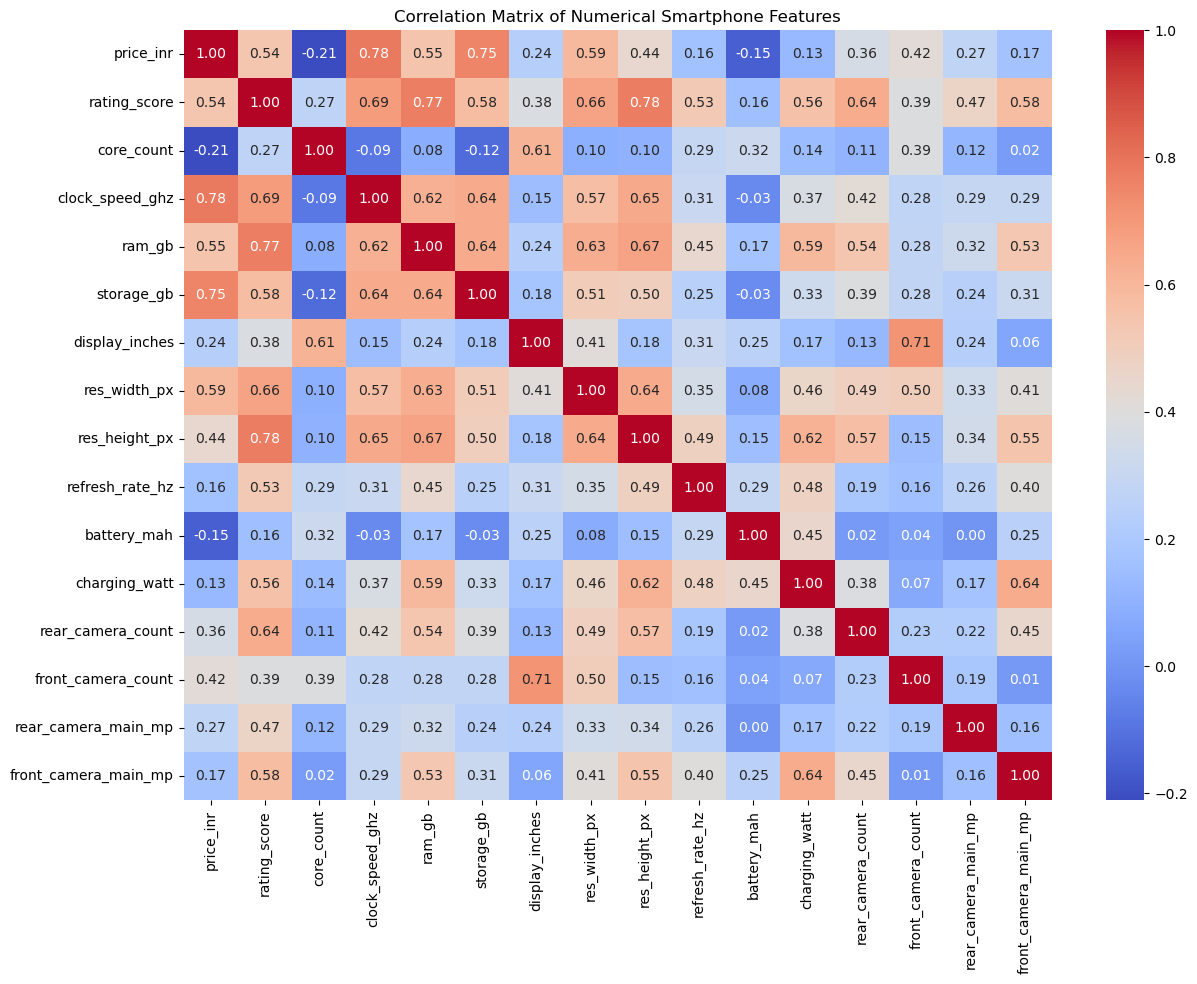

In [28]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Smartphone Features")

plt.show()

In [29]:
features = [
    "ram_gb",
    "storage_gb",
    "rating_score",
    "core_count",
    "clock_speed_ghz",
    "display_inches",
    "refresh_rate_hz",
    "battery_mah",
    "charging_watt",
    "rear_camera_main_mp",
    "front_camera_main_mp"
]

target = "price_inr"

X = df[features]
y = df[target]

print("Features:")
print(features)

print("\nTarget:")
print(target)

Features:
['ram_gb', 'storage_gb', 'rating_score', 'core_count', 'clock_speed_ghz', 'display_inches', 'refresh_rate_hz', 'battery_mah', 'charging_watt', 'rear_camera_main_mp', 'front_camera_main_mp']

Target:
price_inr


In [30]:
print(X.isnull().sum())
print("\nTarget missing values:", y.isnull().sum())

ram_gb                  0
storage_gb              0
rating_score            0
core_count              0
clock_speed_ghz         0
display_inches          0
refresh_rate_hz         0
battery_mah             0
charging_watt           0
rear_camera_main_mp     0
front_camera_main_mp    5
dtype: int64

Target missing values: 0


In [31]:
model_df = df[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

print("Dataset size after removing missing values:", model_df.shape)

Dataset size after removing missing values: (753, 12)


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 602
Testing samples: 151


In [33]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [34]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[ 28839.70920375  23141.71418443 137891.2460129   49121.39510424
  21807.09401158  22531.37225728  11252.36459749  21559.39519758
 113713.79264404  20386.28158428]


In [35]:
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score:", r2)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

R² Score: 0.6724474478177529
Mean Absolute Error: 10069.182876308476
Root Mean Squared Error: 16856.033774885735


In [36]:
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("R² Score:", r2)
print("Adjusted R²:", adjusted_r2)

R² Score: 0.6724474478177529
Adjusted R²: 0.6465260228249132


In [37]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,ram_gb,637.051938
1,storage_gb,70.851859
2,rating_score,-58.914915
3,core_count,-8199.481695
4,clock_speed_ghz,30381.491180
5,display_inches,42071.114516
6,refresh_rate_hz,-42.402739
7,battery_mah,-4.343990
8,charging_watt,-215.619064
9,rear_camera_main_mp,-0.738821


In [38]:
print("Model Intercept:", model.intercept_)

Model Intercept: -245481.79233557964


In [39]:
coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
5,display_inches,42071.114516
4,clock_speed_ghz,30381.491180
0,ram_gb,637.051938
1,storage_gb,70.851859
10,front_camera_main_mp,37.015762
9,rear_camera_main_mp,-0.738821
7,battery_mah,-4.343990
6,refresh_rate_hz,-42.402739
2,rating_score,-58.914915
8,charging_watt,-215.619064


In [40]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,26099,28839.709204
1,35999,23141.714184
2,83999,137891.246013
3,45999,49121.395104
4,9480,21807.094012
5,22307,22531.372257
6,15999,11252.364597
7,20348,21559.395198
8,89998,113713.792644
9,50999,20386.281584


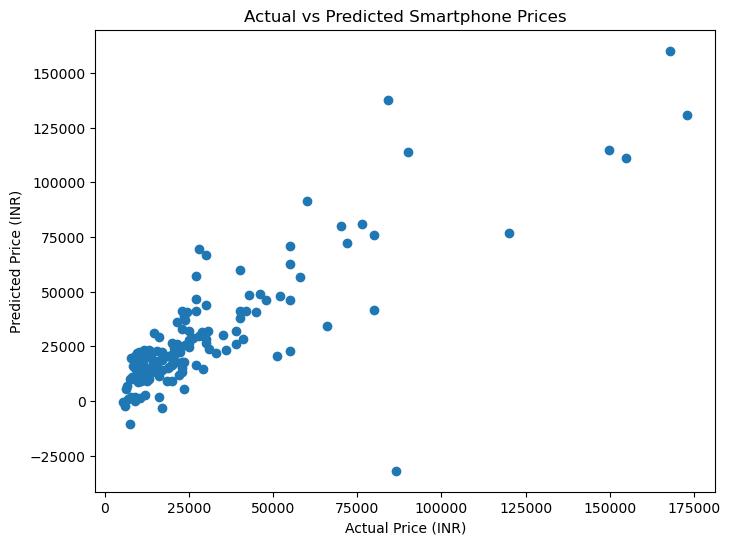

In [41]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price (INR)")
plt.ylabel("Predicted Price (INR)")
plt.title("Actual vs Predicted Smartphone Prices")

plt.show()

In [43]:
X_ram = df[["ram_gb"]]
y_ram = df["price_inr"]

ram_df = pd.concat([X_ram, y_ram], axis=1).dropna()

X_ram = ram_df[["ram_gb"]]
y_ram = ram_df["price_inr"]

X_ram_train, X_ram_test, y_ram_train, y_ram_test = train_test_split(
    X_ram,
    y_ram,
    test_size=0.20,
    random_state=42
)

ram_model = LinearRegression()

ram_model.fit(X_ram_train, y_ram_train)

y_ram_pred = ram_model.predict(X_ram_test)

In [44]:
ram_r2 = r2_score(y_ram_test, y_ram_pred)

ram_mae = mean_absolute_error(y_ram_test, y_ram_pred)

ram_rmse = np.sqrt(
    mean_squared_error(y_ram_test, y_ram_pred)
)

print("RAM-only Model")
print("----------------------")
print("R² Score:", ram_r2)
print("MAE:", ram_mae)
print("RMSE:", ram_rmse)

RAM-only Model
----------------------
R² Score: 0.247403653186007
MAE: 13688.651658464501
RMSE: 21693.90170399454


In [45]:
model_comparison = pd.DataFrame({
    "Model": [
        "RAM Only",
        "Multiple Linear Regression"
    ],
    "R2 Score": [
        ram_r2,
        r2
    ],
    "MAE": [
        ram_mae,
        mae
    ],
    "RMSE": [
        ram_rmse,
        rmse
    ]
})

model_comparison

,Model,R2 Score,MAE,RMSE
0,RAM Only,0.247404,13688.651658,21693.901704
1,Multiple Linear Regression,0.672447,10069.182876,16856.033775


In [46]:
print("RAM coefficient in RAM-only model:", ram_model.coef_[0])
print("RAM-only model intercept:", ram_model.intercept_)

RAM coefficient in RAM-only model: 5960.949996668872
RAM-only model intercept: -17650.339907278412


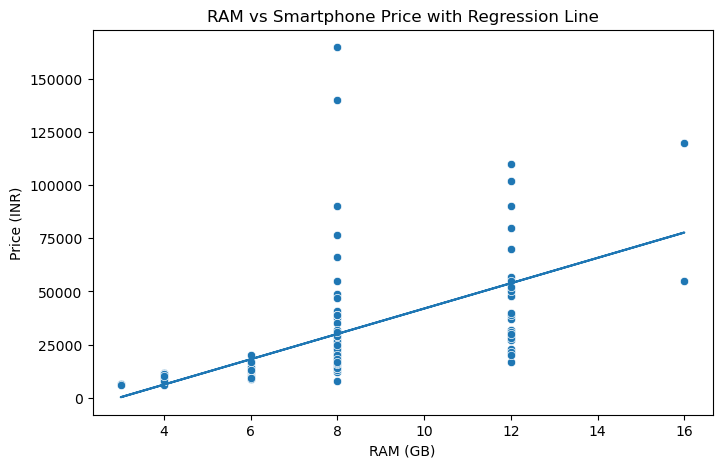

In [47]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=X_ram_test["ram_gb"],
    y=y_ram_test
)

plt.plot(
    X_ram_test["ram_gb"],
    y_ram_pred
)

plt.xlabel("RAM (GB)")
plt.ylabel("Price (INR)")
plt.title("RAM vs Smartphone Price with Regression Line")

plt.show()